![Baseball Flights](baseball_flights.png)


To the Office of Transportation at The 22nd Century Sporting League,

After our inaugural 2101 season, The League is looking for ways to optimize our game scheduling process and costs.  We know that transportation logistics are a major variable to consider during scheduling, and as such, we’ve got a few questions for you. 

Our primary areas of focus are surrounding the number of jets that The League needs to own, and the cost of fuel for those flights. If we want The League to enjoy continued success, we'll need to make sure we manage transportation costs.

We’re sharing schedule data for the upcoming 2102 season.  On each row, you’ll find information about which teams are needing to travel to their next set of games, the time the flight will likely depart (based on our estimations of gameplay durations) and the time the flight will likely land. 

Additionally, we're also providing the fuel price that was paid each day during this past 2101 season. The fuel price fluctuates over time, but we're hoping you'll be able to project it to the future to help with the analysis.

## The Data

### team_flights.csv

| Column     | Description              |
|------------|--------------------------|
| `team_name` | Official team name |
| `departure_datetime` | Date and Time (in UTC) when the flight will depart |
| `landing_datetime` | Date and Time (in UTC) when the flight will land |


### fuel_price.csv

| Column     | Description              |
|------------|--------------------------|
| `date` | Date when the fuel price was recorded |
| `fuel_price` | Corresponding fuel price (in $ per gallon) |


### Important Things to Know
- You can assume that the flight's average speed is 500 MPH. (So, as an example, a 2-hour flight would travel 1000 miles)
- You can assume that each team’s jet fills up with fuel equivalent to 1 gallon per mile-of-travel 
- You can assume that the jet is fueled on the day the travel departs (and thus can use the fuel price corresponding to the departure date)

In [1]:
# Import required modules
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns


# Explore the data
team_flights = pd.read_csv('./team_flights.csv')
fuel_prices = pd.read_csv('./fuel_prices_2101.csv',
                         index_col='date')

team_flights.head()

# Some basic data cleaning and pre-processing
team_flights['departure_datetime'] = pd.to_datetime(team_flights['departure_datetime'])
team_flights['landing_datetime']   = pd.to_datetime(team_flights['landing_datetime'])

fuel_prices.index = pd.DatetimeIndex(fuel_prices.index).to_period('D')

### Find the cucurrent in flights for each datetime point
* the idea is to find out for each departure_datetime and landing_datetime, how many concurrent in-flight are there and then find the max
* first find all the unique datetime among all departure_datetime and landing_datetime
* traverse each datetime, and for each of them, find the total number of flights that are in-flight at that datetime by departure_datetime>=datetime<landing_datetime
* find the max of them and you can also visualize the distribution of the concurrent in-flight number 

In [2]:
team_flights.head()

,team_name,departure_datetime,landing_datetime,travel_distance_miles
0,Agile Antelopes,2102-04-06 21:37:00,2102-04-07 00:35:57,1491.250000
1,Agile Antelopes,2102-04-10 23:57:00,2102-04-11 01:35:40,822.222222
2,Agile Antelopes,2102-04-14 00:29:00,2102-04-14 05:02:55,2282.638889
3,Agile Antelopes,2102-04-21 03:31:00,2102-04-21 05:23:09,934.583333
4,Agile Antelopes,2102-04-24 22:23:00,2102-04-25 00:25:50,1023.611111


#### get all datetime points among departure_datetime and landing_datetime
* get the list of all unique datetime
* convert to pd.Series and then to dataframe, set the datetime to 'date' column
* calcuate in_flight for each datetime and assign to 'in_flight' column

In [3]:
departs = set(team_flights['departure_datetime'])
landings = set(team_flights['landing_datetime'])

all_datetimes = list(departs | landings)
all_datetimes.sort()

In [4]:
all_datetimes[:5]

[Timestamp('2102-04-03 21:40:00'),
 Timestamp('2102-04-03 21:52:00'),
 Timestamp('2102-04-03 22:02:00'),
 Timestamp('2102-04-03 22:04:00'),
 Timestamp('2102-04-03 22:19:00')]

In [5]:
all_datetime_df = pd.Series(all_datetimes).to_frame("date")
all_datetime_df['in_flight'] = 0
all_datetime_df = all_datetime_df.set_index('date', drop=True)
all_datetime_df.head()

,in_flight
date,
2102-04-03 21:40:00,0
2102-04-03 21:52:00,0
2102-04-03 22:02:00,0
2102-04-03 22:04:00,0
2102-04-03 22:19:00,0


In [6]:
rs = 0

for index, datetime in  enumerate(all_datetime_df.index):
    d_rs = team_flights.query("departure_datetime<=@datetime & landing_datetime>@datetime").shape[0]
    all_datetime_df.iloc[index, 0] = d_rs    

all_datetime_df.head()
print(all_datetime_df['in_flight'].max())



19


Text(0.5, 1.0, 'Number of Teams In Flight')

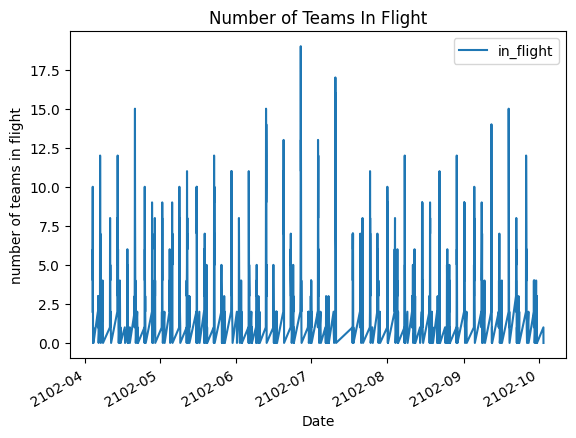

In [7]:
ax = all_datetime_df.plot()
ax.set_xlabel("Date")
ax.set_ylabel("number of teams in flight")
ax.set_title("Number of Teams In Flight")

In [8]:
max_teams_in_flight = 19

### Get the forecast of fule price by SARIMA
* data visualization shows a linear trend and sesonality
* use diff to consider trend, and then find the seasonality by plot_acf and plot_pacf
* to find the order for non-seasonality, use data.diff().diff(7)
* set d=1, and the corresponding p and q, run adfuller test to make sure stationary for non-seasonality
* find the pattern of seasonality by data.diff(), and plot_acf and plot_pacf with s_lag=\[7,14,21,28,35\] if apparent pattern is find, then D=0, otherwise, try data.diff().diff(7) to exclude potential seasonality trend and check plot_acf and plot_pacf
* fit SARMIA model using data with p,d,q and P,D,Q

<Axes: xlabel='date'>

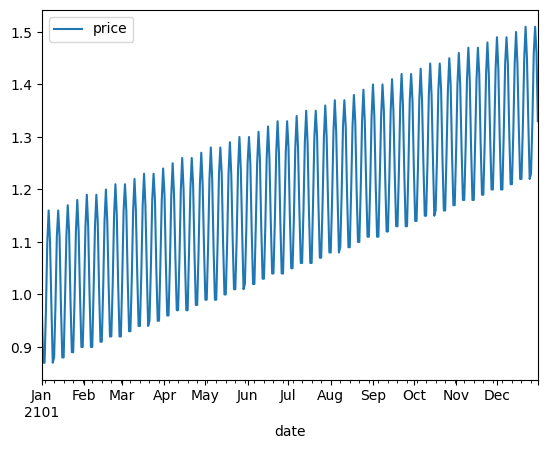

In [9]:
fuel_prices.plot()

#### plot_acf and plot_pacf on data.diff().diff(7) showed apparent MA(1)
* we will set order = (0,1,1) for non-seasonality

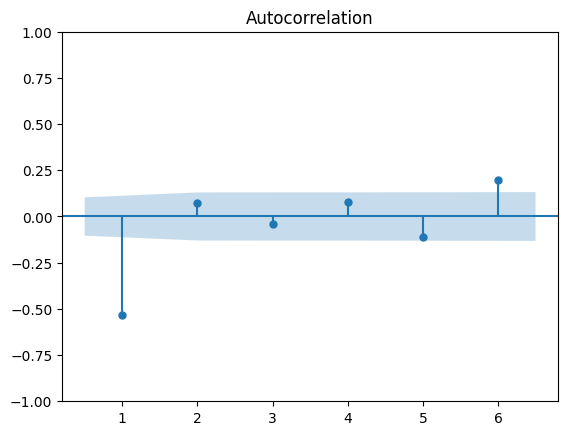

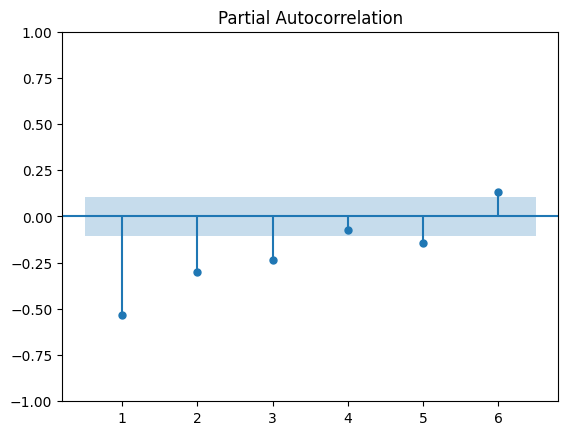

In [10]:
fuel_diff_b = fuel_prices.diff().diff(7).dropna()
fuel_diff = fuel_prices.diff().dropna()
plot_acf(fuel_diff_b, lags=6, zero=False);
plot_pacf(fuel_diff_b, lags=6, zero=False);

#### plot_acf and plot_pacf show apparent AR(1) on data.diff()
* we set seasonal_order = (1, 0, 0) since we don't see seasonality trend and MA 

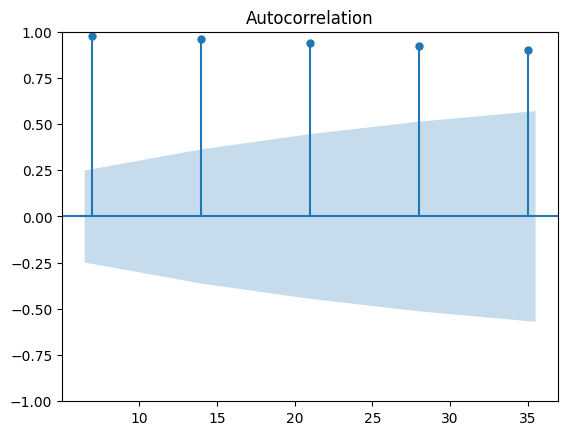

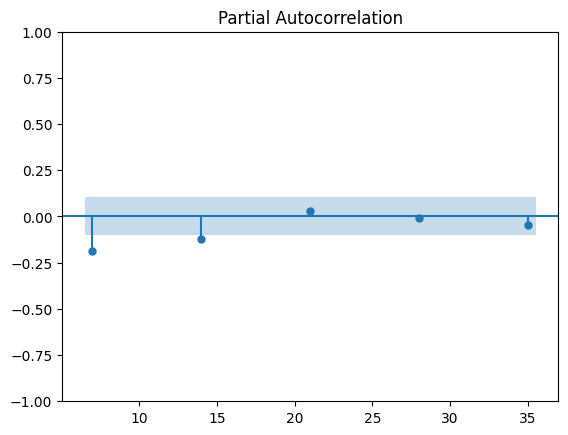

In [11]:
s_lags= [7, 14, 21, 28, 35]
plot_acf(fuel_diff, lags=s_lags, zero=False);
plot_pacf(fuel_diff, lags=s_lags, zero=False);

#### run augmented dicky-fuller test on stationary of non-seasonality

1.0489878228701221e-08


<Axes: xlabel='date'>

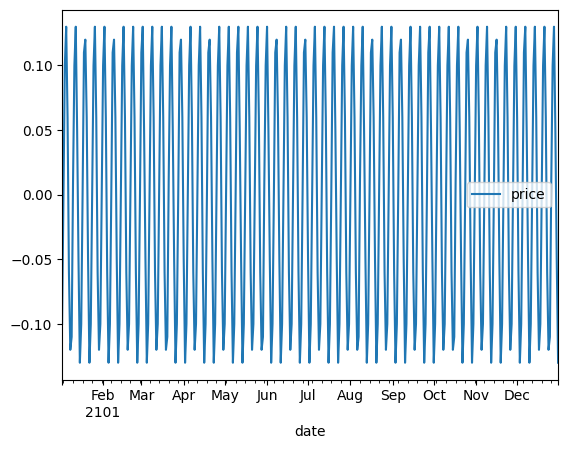

In [12]:
print(adfuller(fuel_diff)[1])
fuel_diff.plot()

#### fit SARIMA model
* the residal didn't show normal distribution
* dependency test passed prob(Q)
* some residul lag 7 was observed

In [13]:
model = SARIMAX(fuel_prices, order=(0, 1, 1), seasonal_order=(1,0,0,7))
model_result = model.fit()
print(model_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  365
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 7)   Log Likelihood                1414.327
Date:                            Wed, 11 Mar 2026   AIC                          -2822.655
Time:                                    08:10:28   BIC                          -2810.963
Sample:                                01-01-2101   HQIC                         -2818.008
                                     - 12-31-2101                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9810      0.009   -109.224      0.000      -0.999      -0.963
ar.S.L7        0.9979      0.001   

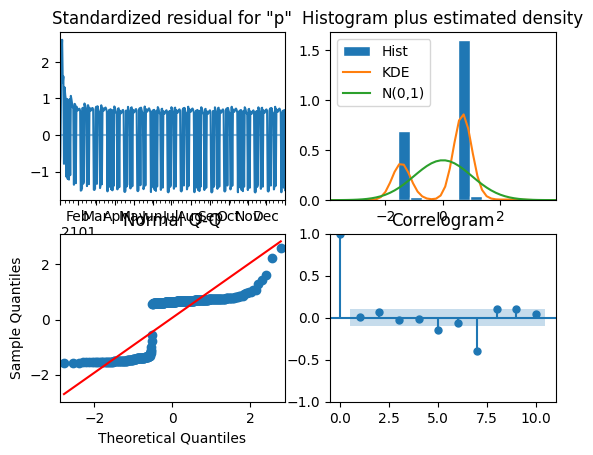

In [14]:
model_result.plot_diagnostics();

#### get fuel price forecast for the next year (2102)
* convert the predicted_mean as a series to dataframe, and convert the periodindex to timestamp
* convert the index to a column and then timestamp to date

In [15]:
fuel_forecast = model_result.get_forecast(steps=365)
fuel_forecast_mean_df = pd.DataFrame({'date':fuel_forecast.predicted_mean.index.to_timestamp(), 'price': fuel_forecast.predicted_mean})
fuel_forecast_mean_df['date'] = fuel_forecast_mean_df['date'].dt.date

fuel_forecast_mean_df.columns

Index(['date', 'price'], dtype='object')

#### extract departur_datetime from team_flights dataframe
* convert departure_datetime column to date datatype
* merge fuel_forecast_mean_df with team_flights dataframe by departure_datetime and date columns
* multiply price and travel_distance_miles columns to obtain flight costs based on assumption of 1 gallon per mile to get price for each flight
* get total cost by sum of flight cost

In [16]:
team_flights.columns

Index(['team_name', 'departure_datetime', 'landing_datetime',
       'travel_distance_miles'],
      dtype='object')

In [17]:
team_flights_by_date = team_flights[['team_name', 'departure_datetime', 'travel_distance_miles']]
team_flights_by_date['departure_datetime'] = team_flights_by_date['departure_datetime'].dt.date
team_flights_by_date.head()

C:\Users\huang\AppData\Local\Temp\ipykernel_290844\1270427563.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_flights_by_date['departure_datetime'] = team_flights_by_date['departure_datetime'].dt.date


,team_name,departure_datetime,travel_distance_miles
0,Agile Antelopes,2102-04-06,1491.250000
1,Agile Antelopes,2102-04-10,822.222222
2,Agile Antelopes,2102-04-14,2282.638889
3,Agile Antelopes,2102-04-21,934.583333
4,Agile Antelopes,2102-04-24,1023.611111


In [18]:
fuel_prices.head()

,price
date,
2101-01-01,0.97
2101-01-02,0.87
2101-01-03,0.87
2101-01-04,0.97
2101-01-05,1.10


In [19]:
team_flights_fuel_price = pd.merge(fuel_forecast_mean_df, team_flights_by_date, left_on="date", right_on="departure_datetime")

In [20]:
team_flights_fuel_price.head()

,date,price,team_name,departure_datetime,travel_distance_miles
0,2102-04-03,1.32895,Daring Dragons,2102-04-03,257.083333
1,2102-04-03,1.32895,Elegant Eagles,2102-04-03,833.194444
2,2102-04-03,1.32895,Proud Panthers,2102-04-03,76.388889
3,2102-04-03,1.32895,Quick Quails,2102-04-03,938.750000
4,2102-04-03,1.32895,Rapid Rabbits,2102-04-03,781.111111


In [21]:
total_fuel_spend_2102_dollars = sum(team_flights_fuel_price['price'] * team_flights_fuel_price['travel_distance_miles'])
print(total_fuel_spend_2102_dollars)

1859754.4314884976


### Try DeterministicProcess(DP)
* using SARIMA alone didn't get good model fitting
  + the residual showed apparent non-normal distribution
  + residuals are not zero centered and has some trend in early data points
  + correlogram showed an apparent lag at 7
* combining DP and SARIMA
  + using DP to encode the weekly trend by one-hot encoding
  + the residual after DP process showed much clearer MA and AR patterns for non-seasonal and seasonal orders
  + the fitted model showed better zero centered residual, with no apparent lags in correlogram and the distribution is closer to normal

In [40]:
# annotations: https://stackoverflow.com/a/49238256/5769929
def seasonal_plot(X, y, period, freq, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    palette = sns.color_palette("husl", n_colors=X[period].nunique(),)
    ax = sns.lineplot(
        x=freq,
        y=y,
        hue=period,
        data=X,
        ci=False,
        ax=ax,
        palette=palette,
        legend=False,
    )
    ax.set_title(f"Seasonal Plot ({period}/{freq})")
    for line, name in zip(ax.lines, X[period].unique()):
        y_ = line.get_ydata()[-1]
        ax.annotate(
            name,
            xy=(1, y_),
            xytext=(6, 0),
            color=line.get_color(),
            xycoords=ax.get_yaxis_transform(),
            textcoords="offset points",
            size=14,
            va="center",
        )
    return ax


def plot_periodogram(ts, detrend='linear', ax=None):
    from scipy.signal import periodogram
    fs = pd.Timedelta("365D") / pd.Timedelta("1D")
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling='spectrum',
    )
    
    if ax is None:
        _, ax = plt.subplots()
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels(
        [
            "Annual (1)",
            "Semiannual (2)",
            "Quarterly (4)",
            "Bimonthly (6)",
            "Monthly (12)",
            "Biweekly (26)",
            "Weekly (52)",
            "Semiweekly (104)",
        ],
        rotation=30,
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variance")
    ax.set_title("Periodogram")
    return ax

C:\Users\huang\AppData\Local\Temp\ipykernel_290844\1961743264.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  ax = sns.lineplot(


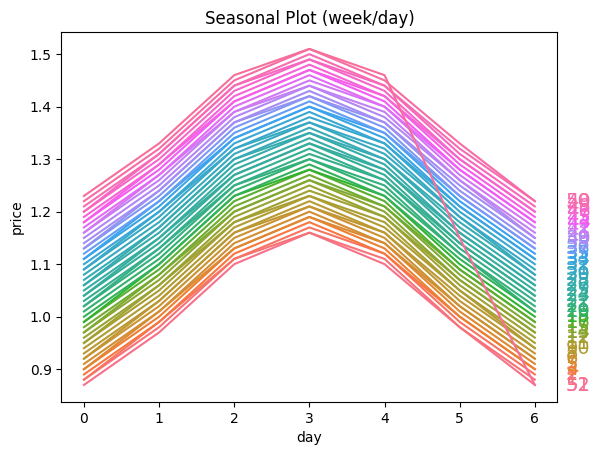

In [41]:
fuel_seasonal = fuel_prices.copy()
fuel_seasonal["week"] = fuel_seasonal.index.week
fuel_seasonal["day"] = fuel_seasonal.index.dayofweek
seasonal_plot(fuel_seasonal, y='price', period="week", freq='day');

<Axes: title={'center': 'Periodogram'}, ylabel='Variance'>

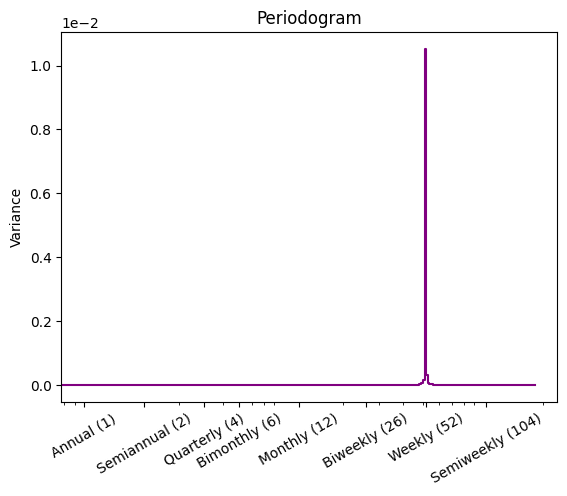

In [42]:
plot_periodogram(fuel_prices.price, detrend='linear', ax=None)

In [43]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
dp = DeterministicProcess(
    index=fuel_prices.index,
    constant=True,
    order=1,
    seasonal=True,
    drop=True
)

X = dp.in_sample()

In [44]:
model_0 =  SARIMAX(fuel_prices, exog=X, order=(0,0,0)).fit()
y_resid = model_0.resid

C:\Users\huang\anaconda3\envs\farm\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


p-value of adfuller test is 0.002288602840682484


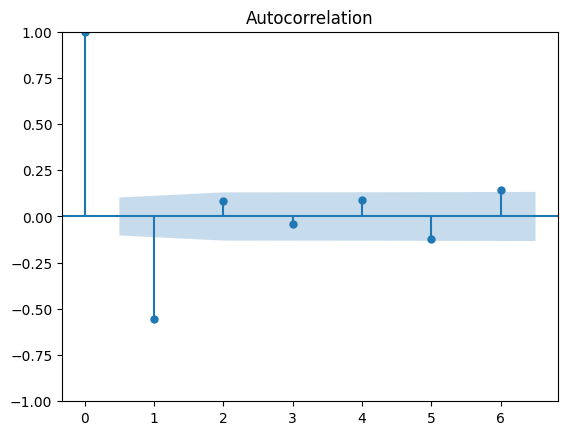

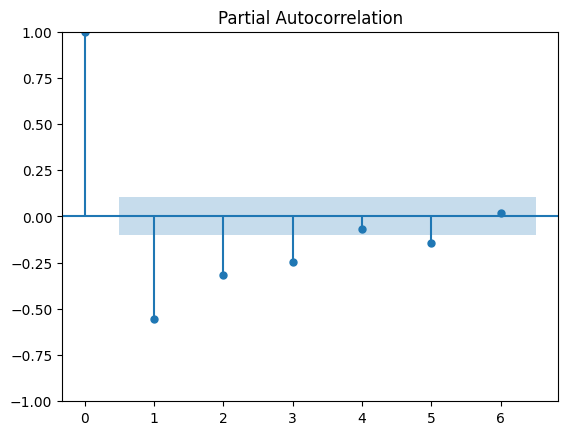

In [45]:
stationary_test = adfuller(y_resid)
print(f"p-value of adfuller test is {stationary_test[1]}")

y_resid_diff = y_resid.diff().dropna()
y_resid_diff_b = y_resid.diff().diff(7).dropna()

plot_acf(y_resid_diff, lags = 6);
plot_pacf(y_resid_diff, lags=6);

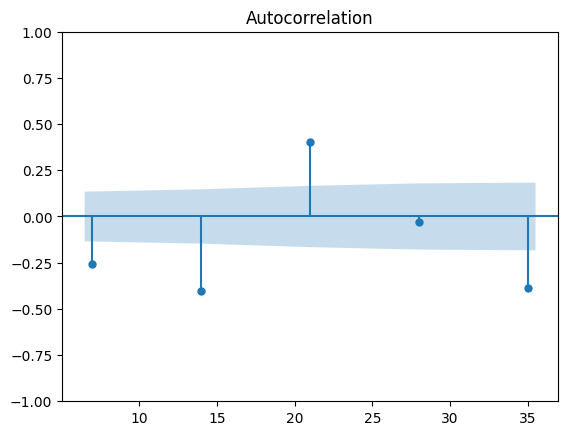

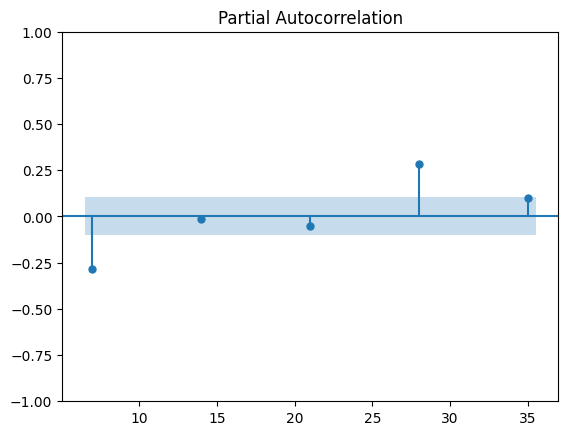

In [46]:
s_lags=[7, 14,21,28,35]
plot_acf(y_resid_diff, lags = s_lags, zero=False);
plot_pacf(y_resid_diff, lags=s_lags, zero=False);

<Axes: xlabel='date'>

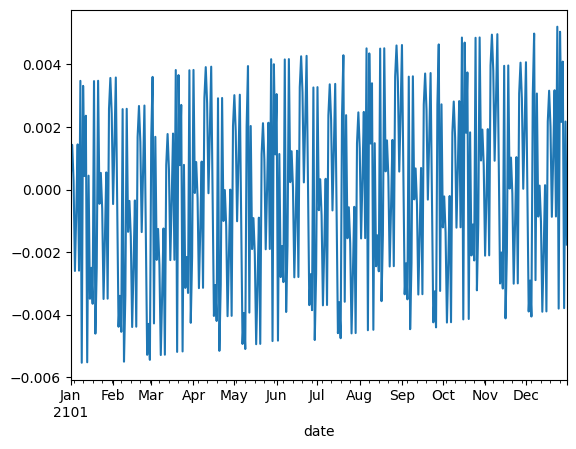

In [47]:
y_resid.plot()

                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                  365
Model:             SARIMAX(0, 1, 1)x(1, 0, [], 7)   Log Likelihood                1605.325
Date:                            Wed, 11 Mar 2026   AIC                          -3188.651
Time:                                    08:28:51   BIC                          -3145.782
Sample:                                01-01-2101   HQIC                         -3171.613
                                     - 12-31-2101                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -6.26e-16   3.25e-11  -1.92e-05      1.000   -6.38e-11    6.38e-11
trend          0.0010   2.74e-05   

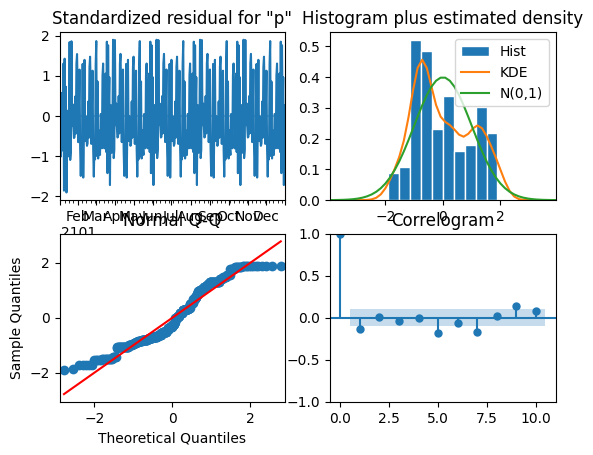

In [48]:
final_model = SARIMAX(fuel_prices, exog=X, order=(0,1,1), seasonal_order=(1,0,0,7)).fit()
print(final_model.summary())
final_model.plot_diagnostics();
                       